# Paths and Imports

In [20]:
import os
import pythermalcomfort
# pin the repo root regardless of where cells run from
if os.path.basename(os.getcwd()) in ("model", "optimization", "data"):
    os.chdir("..")
REPO_ROOT = os.getcwd()
print("repo root:", REPO_ROOT)

repo root: c:\Users\afifb\OneDrive - American University of Beirut\research\HVAC\Meshgraphnet model\MeshGraphNet_training\HVAC_github


# Model Loding

In [14]:
os.chdir(REPO_ROOT)
os.chdir("model")

In [4]:
# ============================================================
# CELL 1: INSTALL + IMPORTS
# ============================================================


import numpy as np
import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
import matplotlib.pyplot as plt
import time


## Loading dataset and splitting


In [5]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================
dataset_dict = torch.load("../data/pyg_dataset.pt", weights_only=False)

train_dataset = dataset_dict["train_dataset"]
val_dataset = dataset_dict["val_dataset"]
test_dataset = dataset_dict["test_dataset"]
train_cases = dataset_dict["train_cases"]
val_cases = dataset_dict["val_cases"]
test_cases = dataset_dict["test_cases"]

print(f"Train: {len(train_dataset)} graphs — cases {train_cases}")
print(f"Val:   {len(val_dataset)} graphs — cases {val_cases}")
print(f"Test:  {len(test_dataset)} graphs — cases {test_cases}")

# Inspect one graph
sample = train_dataset[0]
print(f"\nSample graph:")
print(f"  Node features (x):    {sample.x.shape}   → {sample.x.shape[1]} features per node")
print(f"  Edge index:            {sample.edge_index.shape}")
print(f"  Edge features:         {sample.edge_attr.shape} → {sample.edge_attr.shape[1]} features per edge")
print(f"  Targets (y):           {sample.y.shape}   → {sample.y.shape[1]} targets per node")
print(f"  Case: {sample.case.item()}, T_inlet={sample.T_inlet.item():.1f}K, "
      f"ṁ={sample.mass_flow.item():.3f}, T_out={sample.T_outdoor.item():.1f}K")

Train: 45 graphs — cases [2, 3, 4, 5, 8, 10, 13, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 30, 31, 33, 34, 35, 36, 37, 38, 39, 41, 43, 44, 45, 46, 47, 49, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 65]
Val:   9 graphs — cases [11, 14, 18, 29, 32, 40, 42, 63, 64]
Test:  10 graphs — cases [1, 7, 9, 12, 20, 24, 48, 50, 51, 55]

Sample graph:
  Node features (x):    torch.Size([73841, 12])   → 12 features per node
  Edge index:            torch.Size([2, 645268])
  Edge features:         torch.Size([645268, 4]) → 4 features per edge
  Targets (y):           torch.Size([73841, 5])   → 5 targets per node
  Case: 61, T_inlet=290.6K, ṁ=0.746, T_out=311.4K


## Compute Normalization Stats

In [6]:
# ============================================================
# CELL 3: NORMALIZATION STATS (training set only)
# ============================================================
all_x = torch.stack([d.x for d in train_dataset])      # (39, 73841, 12)
all_y = torch.stack([d.y for d in train_dataset])      # (39, 73841, 5)
edge_attr = train_dataset[0].edge_attr                  # (645268, 4)

# Node features
x_mean = all_x.reshape(-1, 12).mean(dim=0)
x_std  = all_x.reshape(-1, 12).std(dim=0)
x_std[x_std < 1e-8] = 1.0   # constant features get std=1 to avoid division by zero

# Targets
y_mean = all_y.reshape(-1, 5).mean(dim=0)
y_std  = all_y.reshape(-1, 5).std(dim=0)

# Edge features
e_mean = edge_attr.mean(dim=0)
e_std  = edge_attr.std(dim=0)
e_std[e_std < 1e-8] = 1.0

# Print everything
feature_names = ["x", "y", "z",
                 "interior", "people", "desk", "computer", "outside_wall", "wall",
                 "T_inlet", "mass_flow", "T_outdoor"]
target_names = ["T", "U", "V", "W", "G"]
edge_names = ["dx", "dy", "dz", "dist"]

print("NODE FEATURE STATS:")
print(f"  {'Feature':<15s}  {'Mean':>10s}  {'Std':>10s}")
print(f"  {'-'*15}  {'-'*10}  {'-'*10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<15s}  {x_mean[i]:>10.4f}  {x_std[i]:>10.4f}")

print(f"\nTARGET STATS:")
print(f"  {'Target':<5s}  {'Mean':>10s}  {'Std':>10s}")
print(f"  {'-'*5}  {'-'*10}  {'-'*10}")
for i, name in enumerate(target_names):
    print(f"  {name:<5s}  {y_mean[i]:>10.4f}  {y_std[i]:>10.4f}")

print(f"\nEDGE FEATURE STATS:")
print(f"  {'Edge':<5s}  {'Mean':>10s}  {'Std':>10s}")
print(f"  {'-'*5}  {'-'*10}  {'-'*10}")
for i, name in enumerate(edge_names):
    print(f"  {name:<5s}  {e_mean[i]:>10.6f}  {e_std[i]:>10.6f}")

norm_stats = {
    "x_mean": x_mean, "x_std": x_std,
    "y_mean": y_mean, "y_std": y_std,
    "e_mean": e_mean, "e_std": e_std,
}

del all_x, all_y
print("\n✅ Normalization stats computed")

NODE FEATURE STATS:
  Feature                Mean         Std
  ---------------  ----------  ----------
  x                    2.8277      0.2208
  y                    0.6099      0.3440
  z                   -0.9732      0.1055
  interior             0.8917      0.3107
  people               0.0855      0.2796
  desk                 0.0186      0.1351
  computer             0.0000      0.0037
  outside_wall         0.0000      1.0000
  wall                 0.0042      0.0648
  T_inlet            297.2189      6.0051
  mass_flow            0.4720      0.2595
  T_outdoor          296.1256     10.7455

TARGET STATS:
  Target        Mean         Std
  -----  ----------  ----------
  T        299.6641      4.8250
  U         -0.0614      0.0842
  V         -0.0039      0.0376
  W         -0.0062      0.0489
  G       1930.8118     78.7638

EDGE FEATURE STATS:
  Edge         Mean         Std
  -----  ----------  ----------
  dx       0.000000    0.009548
  dy      -0.000000    0.010390
  d

## Architecture

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
  GPU: NVIDIA GeForce RTX 3060 Laptop GPU
  VRAM: 6.4 GB


In [8]:
# ============================================================
# CELL 4: MESHGRAPHNET MODEL
# ============================================================

class MLP(nn.Module):
    """2-hidden-layer MLP with ReLU + optional LayerNorm"""
    def __init__(self, input_dim, output_dim, hidden_dim=128, layer_norm=True):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        self.layer_norm = nn.LayerNorm(output_dim) if layer_norm else None

    def forward(self, x):
        x = self.net(x)
        if self.layer_norm is not None:
            x = self.layer_norm(x)
        return x


class ProcessorBlock(MessagePassing):
    """
    One round of message passing with gradient checkpointing + mixed precision.
    """
    def __init__(self, hidden_dim=128):
        super().__init__(aggr="sum")
        self.edge_mlp = MLP(3 * hidden_dim, hidden_dim, hidden_dim, layer_norm=True)
        self.node_mlp = MLP(2 * hidden_dim, hidden_dim, hidden_dim, layer_norm=True)

    def _edge_update(self, edge_input):
        return self.edge_mlp(edge_input)

    def _node_update(self, node_input):
        return self.node_mlp(node_input)

    def forward(self, x, edge_index, edge_attr):
        row, col = edge_index
        edge_input = torch.cat([edge_attr, x[row], x[col]], dim=-1)

        edge_attr = edge_attr + torch.utils.checkpoint.checkpoint(
            self._edge_update, edge_input, use_reentrant=False
        )

        node_update = self.propagate(edge_index, edge_attr=edge_attr)
        node_input = torch.cat([x, node_update], dim=-1)

        x = x + torch.utils.checkpoint.checkpoint(
            self._node_update, node_input, use_reentrant=False
        )

        return x, edge_attr

    def message(self, edge_attr):
        return edge_attr

class MeshGraphNet(nn.Module):
    """
    Full Encode-Process-Decode MeshGraphNet

    Encoder:   12 node features → 128,  4 edge features → 128
    Processor: 15 rounds of message passing with residual connections
    Decoder:   128 → 5 targets (T, U, V, W, G)
    """
    def __init__(self, node_in=12, edge_in=4, target_out=5,
                 hidden_dim=128, num_layers=15, norm_stats=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        if norm_stats is None:
            raise ValueError("norm_stats required")

        # Store normalization stats as buffers (move to GPU with model)
        self.register_buffer("x_mean", norm_stats["x_mean"])
        self.register_buffer("x_std", norm_stats["x_std"])
        self.register_buffer("y_mean", norm_stats["y_mean"])
        self.register_buffer("y_std", norm_stats["y_std"])
        self.register_buffer("e_mean", norm_stats["e_mean"])
        self.register_buffer("e_std", norm_stats["e_std"])

        # Encoder
        self.node_encoder = MLP(node_in, hidden_dim, hidden_dim, layer_norm=True)
        self.edge_encoder = MLP(edge_in, hidden_dim, hidden_dim, layer_norm=True)

        # Processor: 15 separate blocks, each with own weights
        self.processor_blocks = nn.ModuleList([
            ProcessorBlock(hidden_dim) for _ in range(num_layers)
        ])

        # Decoder (no LayerNorm — outputs physical values)
        self.decoder = MLP(hidden_dim, target_out, hidden_dim, layer_norm=False)

    def forward(self, data):
      x = data.x
      edge_index = data.edge_index
      edge_attr = data.edge_attr

      # Normalize inputs
      x = (x - self.x_mean) / self.x_std
      edge_attr = (edge_attr - self.e_mean) / self.e_std

      # Encode
      x = self.node_encoder(x)
      edge_attr = self.edge_encoder(edge_attr)

      # Process
      for block in self.processor_blocks:
          x, edge_attr = block(x, edge_index, edge_attr)

      # Decode (normalized output)
      pred_norm = self.decoder(x)

      # Denormalize for evaluation
      pred_phys = pred_norm * self.y_std + self.y_mean

      return pred_norm, pred_phys


# Build the model
model = MeshGraphNet(
    node_in=12,
    edge_in=4,
    target_out=5,
    hidden_dim=128,
    num_layers=10,
    norm_stats=norm_stats,
).to(device)
# Add this after model = MeshGraphNet(...).to(device)


n_params = sum(p.numel() for p in model.parameters())
print(f"Model: MeshGraphNet")
print(f"  Hidden dim:      128")
print(f"  Processor layers: 10")
print(f"  Parameters:      {n_params:,}")
print(f"  Device:          {device}")

Model: MeshGraphNet
  Hidden dim:      128
  Processor layers: 10
  Parameters:      1,589,893
  Device:          cuda


## Loading the Model

In [9]:
import os
import torch

# ── Model path (folder you gave + the trial-2 filename) ──────
MODEL_PATH = "model.pt"

assert os.path.exists(MODEL_PATH), f"NOT FOUND:\n{MODEL_PATH}"
print(f"File found ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")
# ── 2. Architecture must already be instantiated ────────────
try:
    model
except NameError:
    raise NameError("`model` is not defined. Run the model-definition cell first, "
                    "then this script. load_state_dict needs the architecture in memory.")

# ── 3. Load weights and check key match ─────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state = torch.load(MODEL_PATH, map_location=device, weights_only=False)

missing, unexpected = model.load_state_dict(state, strict=False)
if missing or unexpected:
    print(f"WARNING missing keys ({len(missing)}): {missing[:5]}")
    print(f"WARNING unexpected keys ({len(unexpected)}): {unexpected[:5]}")
    print("Architecture in memory does NOT fully match the saved model.")
else:
    print("All weight keys matched (architecture is consistent)")

model.eval().to(device)
if hasattr(model, "y_mean"):
    print(f"Normalization buffer y_mean loaded: {model.y_mean.flatten().tolist()}")

# ── 4. Sanity forward pass on a real sample ─────────────────
ds = torch.load("../data/pyg_dataset.pt", weights_only=False)

sample = ds["test_dataset"][0].to(device)
with torch.no_grad():
    _, pred = model(sample)

print(f"\nForward pass OK, output shape {tuple(pred.shape)}")
print(f"  NaNs: {torch.isnan(pred).sum().item()}   Infs: {torch.isinf(pred).sum().item()}")

names = ["T (degC)", "U (m/s)", "V (m/s)", "W (m/s)", "G (W/m2)"]
for i, nm in enumerate(names):
    col = pred[:, i]
    lo, hi = col.min().item(), col.max().item()
    if i == 0:                     # temperature: K -> C
        lo, hi = lo - 273.15, hi - 273.15
    print(f"  {nm:<10} range [{lo:>8.3f}, {hi:>8.3f}]  std {col.std().item():.4f}")

File found (6.4 MB)
All weight keys matched (architecture is consistent)
Normalization buffer y_mean loaded: [299.6640625, -0.06140948459506035, -0.0038544991984963417, -0.006218264810740948, 1930.811767578125]

Forward pass OK, output shape (73841, 5)
  NaNs: 0   Infs: 0
  T (degC)   range [  29.799,   33.531]  std 0.5488
  U (m/s)    range [  -0.138,    0.043]  std 0.0421
  V (m/s)    range [  -0.068,    0.049]  std 0.0189
  W (m/s)    range [  -0.108,    0.169]  std 0.0272
  G (W/m2)   range [1922.949, 2057.011]  std 22.0294


# Optimization

In [24]:
os.chdir(REPO_ROOT)
os.chdir("optimization")

## Baseline Values

Loaded: 15821 records
Working hours (8-18): 7615 records
Saved: rbc_baseline_hourly.csv (7615 rows)

Total energy:      13899.43 kWh
Mean daily energy: 19.91 kWh/day
Max daily energy:  56.41 kWh/day
Min daily energy:  1.67 kWh/day

Heating hours: 2107
Cooling hours: 5508
Neutral hours: 0


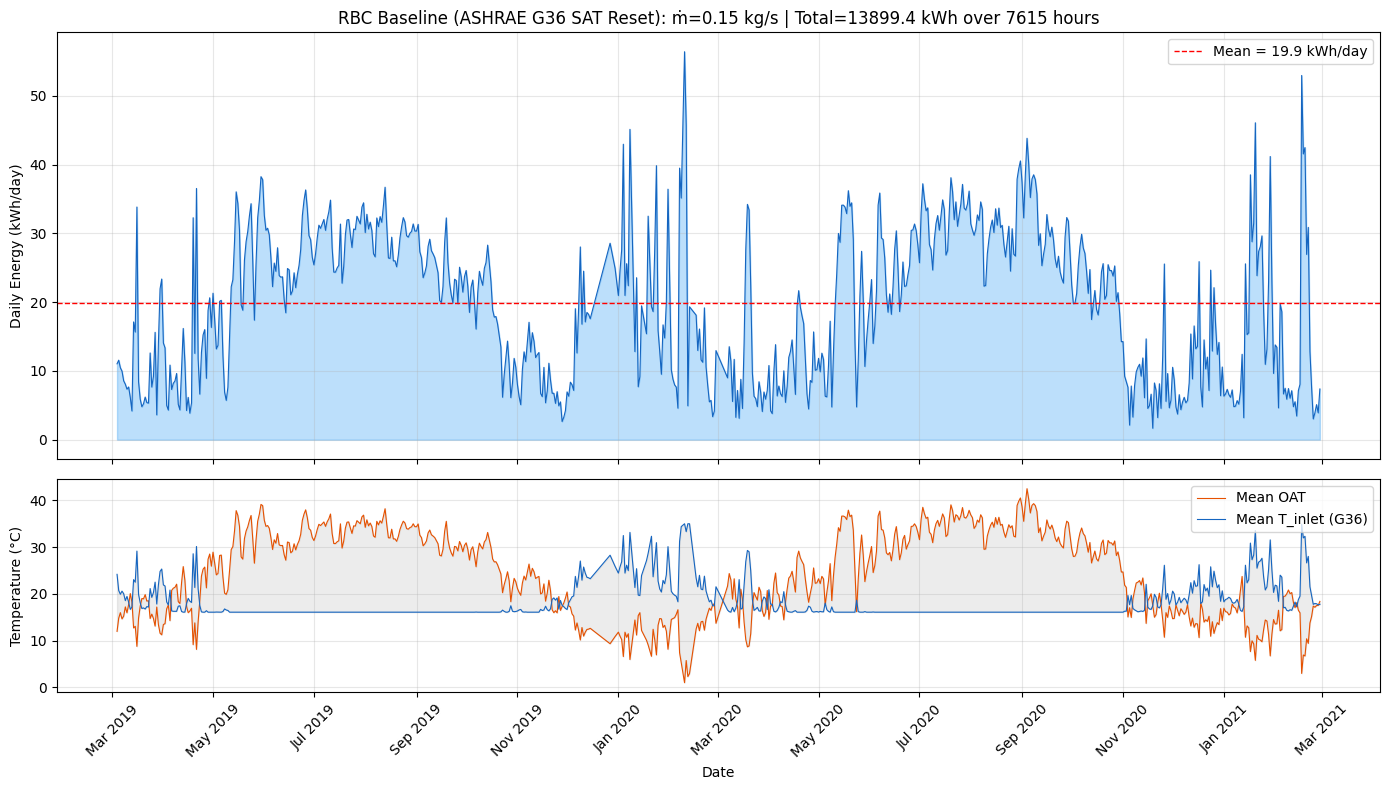

Saved: rbc_baseline_daily_Q.png


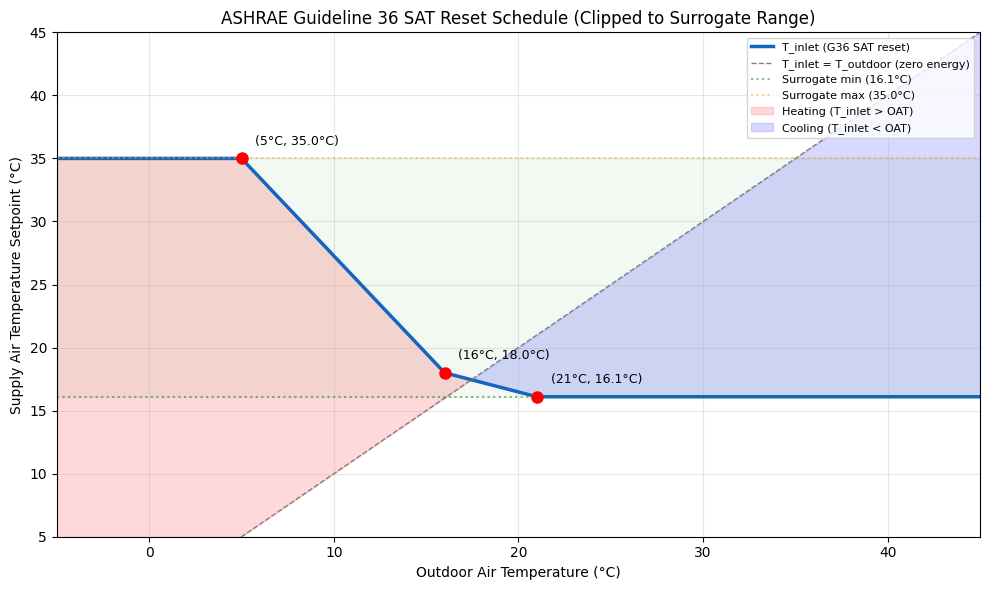

Saved: rbc_sat_reset_schedule.png


In [16]:
"""
RBC Baseline Energy Computation
ASHRAE Guideline 36 SAT reset, clipped to surrogate range [16.1, 35.0]°C
ṁ = 0.15 kg/s fixed
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─── Constants ───────────────────────────────────────────────────
M_DOT = 0.15
CP = 1006.43
T_INLET_MIN = 16.1   # clipped cooling minimum (surrogate range)
T_INLET_MAX = 35.0   # heating maximum (ASHRAE G36 Addendum z)

# ─── SAT reset function ─────────────────────────────────────────
def sat_reset(oat):
    """
    ASHRAE G36 piecewise-linear SAT reset, clipped to [16.1, 35.0]°C.
    
    OAT < 5        → 35.0°C
    5 ≤ OAT < 16   → 35.0 − 1.545 × (OAT − 5)     [35 → 18]
    16 ≤ OAT < 21  → 18.0 − 0.38 × (OAT − 16)      [18 → 16.1]
    OAT ≥ 21       → 16.1°C
    """
    if oat < 5:
        return T_INLET_MAX
    elif oat < 16:
        return 35.0 - 1.545 * (oat - 5)
    elif oat < 21:
        return 18.0 - 0.38 * (oat - 16)
    else:
        return T_INLET_MIN

# ─── Step 1: Load ────────────────────────────────────────────────
hourly = pd.read_csv("hourly_temperature.csv")
hourly['datetime'] = pd.to_datetime(hourly['datetime'])
hourly['hour'] = hourly['datetime'].dt.hour
hourly['date'] = hourly['datetime'].dt.date
print(f"Loaded: {len(hourly)} records")

# ─── Step 2: Filter working hours ────────────────────────────────
working = hourly[(hourly['hour'] >= 8) & (hourly['hour'] <= 18)].copy()
print(f"Working hours (8-18): {len(working)} records")

# ─── Step 3: Compute T_inlet per hour ────────────────────────────
working['T_inlet_C'] = working['T_outdoor_C'].apply(sat_reset)

# ─── Step 4: Clip to surrogate range ─────────────────────────────
working['T_inlet_C'] = working['T_inlet_C'].clip(T_INLET_MIN, T_INLET_MAX)

# ─── Step 5: Compute Q ───────────────────────────────────────────
working['Q_W'] = M_DOT * CP * np.abs(working['T_inlet_C'] - working['T_outdoor_C'])
working['Q_kWh'] = working['Q_W'] / 1000.0

# ─── Step 6: Save hourly CSV ─────────────────────────────────────
output_cols = ['datetime', 'T_outdoor_C', 'T_inlet_C', 'Q_W', 'Q_kWh']
working[output_cols].to_csv("rbc_baseline_hourly.csv", index=False)
print(f"Saved: rbc_baseline_hourly.csv ({len(working)} rows)")

# ─── Step 7: Daily totals ────────────────────────────────────────
daily = working.groupby('date').agg(
    Q_daily_kWh=('Q_kWh', 'sum'),
    T_outdoor_mean=('T_outdoor_C', 'mean'),
    T_inlet_mean=('T_inlet_C', 'mean'),
    n_hours=('Q_kWh', 'count')
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])

total_kWh = working['Q_kWh'].sum()
mean_daily = daily['Q_daily_kWh'].mean()

print(f"\nTotal energy:      {total_kWh:.2f} kWh")
print(f"Mean daily energy: {mean_daily:.2f} kWh/day")
print(f"Max daily energy:  {daily['Q_daily_kWh'].max():.2f} kWh/day")
print(f"Min daily energy:  {daily['Q_daily_kWh'].min():.2f} kWh/day")

# Count heating vs cooling hours
n_heating = (working['T_inlet_C'] > working['T_outdoor_C']).sum()
n_cooling = (working['T_inlet_C'] < working['T_outdoor_C']).sum()
n_neutral = (working['T_inlet_C'] == working['T_outdoor_C']).sum()
print(f"\nHeating hours: {n_heating}")
print(f"Cooling hours: {n_cooling}")
print(f"Neutral hours: {n_neutral}")

# ─── Step 8: Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

# Top: daily Q
ax1 = axes[0]
ax1.fill_between(daily['date'], daily['Q_daily_kWh'], alpha=0.3, color='#2196F3')
ax1.plot(daily['date'], daily['Q_daily_kWh'], linewidth=0.8, color='#1565C0')
ax1.axhline(y=mean_daily, color='red', linestyle='--', linewidth=1,
            label=f'Mean = {mean_daily:.1f} kWh/day')
ax1.set_ylabel('Daily Energy (kWh/day)')
ax1.set_title(f'RBC Baseline (ASHRAE G36 SAT Reset): ṁ={M_DOT} kg/s | '
              f'Total={total_kWh:.1f} kWh over {len(working)} hours')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: T_outdoor and T_inlet
ax2 = axes[1]
ax2.plot(daily['date'], daily['T_outdoor_mean'], linewidth=0.8, color='#E65100',
         label='Mean OAT')
ax2.plot(daily['date'], daily['T_inlet_mean'], linewidth=0.8, color='#1565C0',
         label='Mean T_inlet (G36)')
ax2.fill_between(daily['date'], daily['T_outdoor_mean'], daily['T_inlet_mean'],
                 alpha=0.15, color='grey')
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("rbc_baseline_daily_Q.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: rbc_baseline_daily_Q.png")
# ─── Plot: SAT reset schedule ─────────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 6))

oat_range = np.linspace(-5, 45, 500)
t_inlet_range = np.array([sat_reset(o) for o in oat_range])

ax.plot(oat_range, t_inlet_range, linewidth=2.5, color='#1565C0', label='T_inlet (G36 SAT reset)')
ax.plot(oat_range, oat_range, linewidth=1, color='grey', linestyle='--', label='T_inlet = T_outdoor (zero energy)')

# Mark breakpoints
breakpoints = [(5, 35.0), (16, 18.0), (21, 16.1)]
for oat_bp, t_bp in breakpoints:
    ax.plot(oat_bp, t_bp, 'o', color='red', markersize=8, zorder=5)
    ax.annotate(f'({oat_bp}°C, {t_bp}°C)', xy=(oat_bp, t_bp),
                xytext=(10, 10), textcoords='offset points', fontsize=9)

# Surrogate range shading
ax.axhline(y=16.1, color='green', linestyle=':', alpha=0.5, label='Surrogate min (16.1°C)')
ax.axhline(y=35.0, color='orange', linestyle=':', alpha=0.5, label='Surrogate max (35.0°C)')
ax.axhspan(16.1, 35.0, alpha=0.05, color='green')

# Fill heating and cooling regions
ax.fill_between(oat_range, t_inlet_range, oat_range,
                where=t_inlet_range > oat_range, alpha=0.15, color='red', label='Heating (T_inlet > OAT)')
ax.fill_between(oat_range, t_inlet_range, oat_range,
                where=t_inlet_range < oat_range, alpha=0.15, color='blue', label='Cooling (T_inlet < OAT)')

ax.set_xlabel('Outdoor Air Temperature (°C)')
ax.set_ylabel('Supply Air Temperature Setpoint (°C)')
ax.set_title('ASHRAE Guideline 36 SAT Reset Schedule (Clipped to Surrogate Range)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 45)
ax.set_ylim(5, 45)

plt.tight_layout()
plt.savefig("rbc_sat_reset_schedule.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: rbc_sat_reset_schedule.png")

### Comfort Helper Functions

In [ ]:
import numpy as np
import torch
from pythermalcomfort.models import pmv_ppd_ashrae, clo_tout
from pythermalcomfort.utilities import v_relative

SIGMA = 5.67e-8
MET = 1.1
RH = 60.0

def compute_tmrt(G):
    """T_MRT (°C) from incident radiation G (W/m²)."""
    return (G / (4 * SIGMA)) ** 0.25 - 273.15

def compute_vmag(U, V, W):
    return np.sqrt(U**2 + V**2 + W**2)

def get_clo(t_outdoor_C):
    """Clothing insulation from outdoor temperature (ASHRAE 55, via pythermalcomfort)."""
    return clo_tout(tout=t_outdoor_C).clo_tout
import warnings
warnings.filterwarnings("ignore", message="Cooling effect could not be calculated")
# Sanity check — summer condition (OAT=30°C → clo≈0.46)
clo_summer = get_clo(30.0)
v_r = v_relative(v=0.1, met=MET)
test = pmv_ppd_ashrae(tdb=25, tr=25, vr=v_r, rh=50, met=MET, clo=clo_summer, limit_inputs=False)
print(f"Summer check (OAT=30°C): CLO={clo_summer:.2f}, PMV={test.pmv}, PPD={test.ppd}")

# Sanity check — winter condition (OAT=0°C → clo≈0.82)
clo_winter = get_clo(0.0)
test2 = pmv_ppd_ashrae(tdb=25, tr=25, vr=v_r, rh=50, met=MET, clo=clo_winter, limit_inputs=False)
print(f"Winter check (OAT=0°C):  CLO={clo_winter:.2f}, PMV={test2.pmv}, PPD={test2.ppd}")

print(f"\nConstants: MET={MET}, RH={RH}%, CLO=clo_tout(T_outdoor)")
print("✅ Block 1 complete.")



Summer check (OAT=30°C): CLO=0.46, PMV=-0.32, PPD=7.2
Winter check (OAT=0°C):  CLO=0.82, PMV=0.35, PPD=7.5

Constants: MET=1.1, RH=60.0%, CLO=clo_tout(T_outdoor)
✅ Block 1 complete.


### Basline Computation with Volumetric PMV

In [ ]:
import numpy as np
import pandas as pd
import torch
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
from pythermalcomfort.models import pmv_ppd_ashrae, clo_tout
from pythermalcomfort.utilities import v_relative

SIGMA_SB = 5.67e-8
MET = 1.1
RH = 60.0
M_DOT = 0.15
template = ds["test_dataset"][0]
def compute_tmrt(G):
    return (G / (4 * SIGMA_SB)) ** 0.25 - 273.15

# Occupied zone mask: y = 0.1 to 1.1m
coords = template.x[:, :3].cpu().numpy()
occ_mask = (coords[:, 1] >= 0.1) & (coords[:, 1] <= 1.1)
print(f"Occupied zone nodes: {occ_mask.sum()}")

rbc = pd.read_csv("rbc_baseline_hourly.csv")
rbc['datetime'] = pd.to_datetime(rbc['datetime'])
print(f"Hours: {len(rbc)}")

template_gpu = template.to(device)
model.eval()

mean_pmv_list = []
std_pmv_list = []
pct_comf_list = []

for idx in tqdm(range(len(rbc)), desc="GNN + vol PMV"):
    row = rbc.iloc[idx]
    
    data = template_gpu.clone()
    data.x[:, 9] = row['T_inlet_C'] + 273.15
    data.x[:, 10] = M_DOT
    data.x[:, 11] = row['T_outdoor_C'] + 273.15
    
    with torch.no_grad():
        _, pred_phys = model(data)
    
    pred = pred_phys[occ_mask].cpu().numpy()
    T_occ    = pred[:, 0] - 273.15
    Vmag_occ = np.sqrt(pred[:, 1]**2 + pred[:, 2]**2 + pred[:, 3]**2)
    Tmrt_occ = compute_tmrt(pred[:, 4])
    
    clo = clo_tout(tout=float(row['T_outdoor_C'])).clo_tout
    vr = v_relative(v=Vmag_occ, met=MET)
    
    res = pmv_ppd_ashrae(tdb=T_occ, tr=Tmrt_occ, vr=vr,
                          rh=RH, met=MET, clo=clo, limit_inputs=False)
    pmv_arr = np.array(res.pmv)
    valid = np.isfinite(pmv_arr)
    pmv_valid = pmv_arr[valid]
    
    mean_pmv_list.append(pmv_valid.mean())
    std_pmv_list.append(pmv_valid.std())
    pct_comf_list.append((np.abs(pmv_valid) <= 0.5).sum() / len(pmv_valid) * 100)

rbc['vol_mean_PMV'] = mean_pmv_list
rbc['vol_std_PMV'] = std_pmv_list
rbc['vol_pct_comfortable'] = pct_comf_list
rbc.to_csv("rbc_baseline_hourly.csv", index=False)

print(f"\n{'='*60}")
print("RBC VOLUMETRIC COMFORT STATISTICS")
print(f"{'='*60}")
pmv_arr = np.array(mean_pmv_list)
print(f"  Mean vol_PMV:       {pmv_arr.mean():.3f}")
print(f"  Std vol_PMV:        {np.array(std_pmv_list).mean():.3f}")
print(f"  Mean % comfortable: {np.array(pct_comf_list).mean():.1f}%")
print(f"  Hours |vol_PMV|≤0.5: {(np.abs(pmv_arr) <= 0.5).sum()} ({100*(np.abs(pmv_arr) <= 0.5).sum()/len(pmv_arr):.1f}%)")
print(f"✅ Saved: rbc_baseline_hourly.csv")

Occupied zone nodes: 60284
Hours: 7615


GNN + vol PMV: 100%|██████████| 7615/7615 [2:23:35<00:00,  1.13s/it]   


RBC VOLUMETRIC COMFORT STATISTICS
  Mean vol_PMV:       0.110
  Std vol_PMV:        0.537
  Mean % comfortable: 49.4%
  Hours |vol_PMV|≤0.5: 6289 (82.6%)
✅ Saved: rbc_baseline_hourly.csv


### Lookup Table — Volumetric PMV Calculations

In [ ]:
import numpy as np
import torch
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
from pythermalcomfort.models import pmv_ppd_ashrae, clo_tout
from pythermalcomfort.utilities import v_relative

SIGMA_SB = 5.67e-8
MET = 1.1
RH = 60.0

def compute_tmrt(G):
    return (G / (4 * SIGMA_SB)) ** 0.25 - 273.15

T_out_grid = np.arange(0, 41, 1, dtype=np.float32)
T_in_grid  = np.arange(16, 36, 1, dtype=np.float32)
mdot_grid  = np.round(np.arange(0.15, 1.01, 0.05, dtype=np.float32), 3)

n_tout, n_tin, n_mdot = len(T_out_grid), len(T_in_grid), len(mdot_grid)
n_total = n_tout * n_tin * n_mdot

coords = template.x[:, :3].cpu().numpy()
X_OCC, Z_OCC = 2.80, -1.0
TOL_XZ, TOL_Y = 0.03, 0.05

head_mask = (
    (np.abs(coords[:, 0] - X_OCC) < TOL_XZ) &
    (np.abs(coords[:, 1] - 1.1) < TOL_Y) &
    (np.abs(coords[:, 2] - Z_OCC) < TOL_XZ)
)
ankle_mask = (
    (np.abs(coords[:, 0] - X_OCC) < TOL_XZ) &
    (np.abs(coords[:, 1] - 0.1) < TOL_Y) &
    (np.abs(coords[:, 2] - Z_OCC) < TOL_XZ)
)
occ_mask = (coords[:, 1] >= 0.1) & (coords[:, 1] <= 1.1)
occ_indices = np.where(occ_mask)[0]

# Subsample 2000 nodes from occupied zone
np.random.seed(42)
SUBSAMPLE = 2000
sub_indices = np.random.choice(occ_indices, SUBSAMPLE, replace=False)
sub_mask = np.zeros(len(coords), dtype=bool)
sub_mask[sub_indices] = True

print(f"Head: {head_mask.sum()}, Ankle: {ankle_mask.sum()}")
print(f"Occupied zone: {occ_mask.sum()}, Subsampled: {SUBSAMPLE}")

T_head_arr   = np.zeros((n_tout, n_tin, n_mdot), dtype=np.float32)
T_ankle_arr  = np.zeros((n_tout, n_tin, n_mdot), dtype=np.float32)
vol_mean_PMV = np.zeros((n_tout, n_tin, n_mdot), dtype=np.float32)
vol_std_PMV  = np.zeros((n_tout, n_tin, n_mdot), dtype=np.float32)
vol_pct_comf = np.zeros((n_tout, n_tin, n_mdot), dtype=np.float32)

template_gpu = template.to(device)
model.eval()

pbar = tqdm(total=n_total, desc="LUT v3")

for i, t_out in enumerate(T_out_grid):
    clo = clo_tout(tout=float(t_out)).clo_tout
    
    chunk_T    = np.zeros((n_tin, n_mdot, SUBSAMPLE), dtype=np.float32)
    chunk_Vmag = np.zeros((n_tin, n_mdot, SUBSAMPLE), dtype=np.float32)
    chunk_Tmrt = np.zeros((n_tin, n_mdot, SUBSAMPLE), dtype=np.float32)
    
    # Phase A: GNN inference
    for j, t_in in enumerate(T_in_grid):
        for k, mdot in enumerate(mdot_grid):
            data = template_gpu.clone()
            data.x[:, 9]  = float(t_in) + 273.15
            data.x[:, 10] = float(mdot)
            data.x[:, 11] = float(t_out) + 273.15

            with torch.no_grad():
                _, pred_phys = model(data)

            pred = pred_phys.cpu().numpy()

            T_head_arr[i, j, k]  = np.median(pred[head_mask, 0]) - 273.15
            T_ankle_arr[i, j, k] = np.median(pred[ankle_mask, 0]) - 273.15

            sub_pred = pred[sub_mask]
            chunk_T[j, k]    = sub_pred[:, 0] - 273.15
            chunk_Vmag[j, k] = np.sqrt(sub_pred[:, 1]**2 + sub_pred[:, 2]**2 + sub_pred[:, 3]**2)
            chunk_Tmrt[j, k] = compute_tmrt(sub_pred[:, 4])

        print(f"    T_out={t_out:.0f}°C: GNN {(j+1)*n_mdot}/{n_tin*n_mdot}", end='\r')
    print()
    # Phase B: PMV computation
    for j in range(n_tin):
        for k in range(n_mdot):
            vr = v_relative(v=chunk_Vmag[j, k], met=MET)
            res = pmv_ppd_ashrae(
                tdb=chunk_T[j, k], tr=chunk_Tmrt[j, k], vr=vr,
                rh=RH, met=MET, clo=clo, limit_inputs=False
            )
            pmv_arr = np.array(res.pmv)
            valid = np.isfinite(pmv_arr)
            pmv_valid = pmv_arr[valid]

            vol_mean_PMV[i, j, k] = pmv_valid.mean()
            vol_std_PMV[i, j, k]  = pmv_valid.std()
            vol_pct_comf[i, j, k] = (np.abs(pmv_valid) <= 0.5).sum() / len(pmv_valid) * 100

            pbar.update(1)

pbar.close()

dT_vert = np.abs(T_head_arr - T_ankle_arr)

np.savez("gnn_lookup_table_v3.npz",
    T_out_grid=T_out_grid, T_in_grid=T_in_grid, mdot_grid=mdot_grid,
    T_head=T_head_arr, T_ankle=T_ankle_arr, dT_vert=dT_vert,
    vol_mean_PMV=vol_mean_PMV, vol_std_PMV=vol_std_PMV, vol_pct_comf=vol_pct_comf
)

feasible = (np.abs(vol_mean_PMV) <= 0.5) & (dT_vert < 3.0)

print(f"\n{'='*60}")
print("LOOKUP TABLE v3 SUMMARY")
print(f"{'='*60}")
print(f"  Total points:  {n_total}")
print(f"  Feasible:      {feasible.sum()} ({100*feasible.sum()/n_total:.1f}%)")

print(f"\n  Per T_outdoor:")
print(f"  {'T_out':>6s}  {'Feas':>5s}  {'/360':>5s}  {'%':>6s}")
for i, t_out in enumerate(T_out_grid):
    n_f = feasible[i].sum()
    print(f"  {t_out:>6.0f}  {n_f:>5d}  {'/360':>5s}  {100*n_f/360:>5.1f}%")

print(f"\n✅ Saved: gnn_lookup_table_v3.npz")

Head: 55, Ankle: 24
Occupied zone: 60284, Subsampled: 2000


LUT v3:   0%|          | 0/14760 [02:29<?, ?it/s]


    T_out=0°C: GNN 360/360


    T_out=1°C: GNN 360/360


    T_out=2°C: GNN 360/360


...

    T_out=38°C: GNN 360/360


    T_out=39°C: GNN 360/360


    T_out=40°C: GNN 360/360


LUT v3: 100%|██████████| 14760/14760 [2:54:05<00:00,  1.41it/s]


LOOKUP TABLE v3 SUMMARY
  Total points:  14760
  Feasible:      3076 (20.8%)

  Per T_outdoor:
   T_out   Feas   /360       %
       0     62   /360   17.2%
       1     72   /360   20.0%
       2     78   /360   21.7%
       3     82   /360   22.8%
       4     83   /360   23.1%
       5     86   /360   23.9%
       6     87   /360   24.2%
       7     84   /360   23.3%
       8     84   /360   23.3%
       9     84   /360   23.3%
      10     82   /360   22.8%
      11     83   /360   23.1%
      12     83   /360   23.1%
      13     80   /360   22.2%
      14     81   /360   22.5%
      15     80   /360   22.2%
      16     80   /360   22.2%
      17     78   /360   21.7%
      18     78   /360   21.7%
      19     76   /360   21.1%
      20     77   /360   21.4%
      21     75   /360   20.8%
      22     74   /360   20.6%
      23     73   /360   20.3%
      24     74   /360   20.6%
      25     71   /360   19.7%
      26     70   /360   19.4%
      27     69   /360   19.2%
     

### Subsample Validation (2000 nodes vs full occupied zone)

In [28]:
import numpy as np
import torch
import warnings
warnings.filterwarnings("ignore")
from pythermalcomfort.models import pmv_ppd_ashrae, clo_tout
from pythermalcomfort.utilities import v_relative

SIGMA_SB = 5.67e-8
MET = 1.1
RH = 60.0

def compute_tmrt(G):
    return (G / (4 * SIGMA_SB)) ** 0.25 - 273.15

ds = torch.load("../data/pyg_dataset.pt", weights_only=False)
test_data = ds["test_dataset"]

coords = test_data[0].x[:, :3].numpy()
occ_mask = (coords[:, 1] >= 0.1) & (coords[:, 1] <= 1.1)
occ_indices = np.where(occ_mask)[0]
n_occ = occ_mask.sum()

np.random.seed(42)
sub_indices = np.random.choice(occ_indices, 2000, replace=False)
sub_mask = np.zeros(len(coords), dtype=bool)
sub_mask[sub_indices] = True

print(f"Full occupied zone: {n_occ} nodes")
print(f"Subsample: 2000 nodes")

print(f"\n{'Case':>5s}  {'ṁ':>6s}  {'full_mean':>10s}  {'sub_mean':>10s}  {'Δmean':>7s}  "
      f"{'full_σ':>7s}  {'sub_σ':>7s}  {'Δσ':>6s}")
print(f"{'-'*5}  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*7}  "
      f"{'-'*7}  {'-'*7}  {'-'*6}")

for d in test_data:
    case_id = d.case.item()
    mdot = d.mass_flow.item()
    t_out = d.x[0, 11].item() - 273.15

    clo = clo_tout(tout=float(t_out)).clo_tout
    y = d.y.numpy()

    # Full occupied zone
    T_full    = y[occ_mask, 0] - 273.15
    Vmag_full = np.sqrt(y[occ_mask, 1]**2 + y[occ_mask, 2]**2 + y[occ_mask, 3]**2)
    Tmrt_full = compute_tmrt(y[occ_mask, 4])

    vr_full = v_relative(v=Vmag_full, met=MET)
    res_full = pmv_ppd_ashrae(tdb=T_full, tr=Tmrt_full, vr=vr_full,
                               rh=RH, met=MET, clo=clo, limit_inputs=False)
    pmv_full = np.array(res_full.pmv)
    pmv_full = pmv_full[np.isfinite(pmv_full)]

    # Subsample
    T_sub    = y[sub_mask, 0] - 273.15
    Vmag_sub = np.sqrt(y[sub_mask, 1]**2 + y[sub_mask, 2]**2 + y[sub_mask, 3]**2)
    Tmrt_sub = compute_tmrt(y[sub_mask, 4])

    vr_sub = v_relative(v=Vmag_sub, met=MET)
    res_sub = pmv_ppd_ashrae(tdb=T_sub, tr=Tmrt_sub, vr=vr_sub,
                              rh=RH, met=MET, clo=clo, limit_inputs=False)
    pmv_sub = np.array(res_sub.pmv)
    pmv_sub = pmv_sub[np.isfinite(pmv_sub)]

    full_mean = pmv_full.mean()
    sub_mean  = pmv_sub.mean()
    full_std  = pmv_full.std()
    sub_std   = pmv_sub.std()

    print(f"{case_id:>5d}  {mdot:>6.3f}  {full_mean:>10.3f}  {sub_mean:>10.3f}  {abs(full_mean-sub_mean):>7.4f}  "
          f"{full_std:>7.3f}  {sub_std:>7.3f}  {abs(full_std-sub_std):>6.4f}")

Full occupied zone: 60284 nodes
Subsample: 2000 nodes

 Case       ṁ   full_mean    sub_mean    Δmean   full_σ    sub_σ      Δσ
-----  ------  ----------  ----------  -------  -------  -------  ------
   20   0.279       2.129       2.133   0.0036    0.364    0.361  0.0026
   24   0.737      -0.099      -0.094   0.0048    0.631    0.631  0.0004
   50   0.977       0.686       0.688   0.0024    0.520    0.519  0.0003
   51   0.058       1.259       1.263   0.0035    0.450    0.453  0.0025
   55   0.073       1.868       1.870   0.0022    0.331    0.335  0.0034
   12   0.767       1.452       1.457   0.0041    0.458    0.456  0.0017
    9   0.207       1.194       1.197   0.0032    0.415    0.417  0.0017
    1   0.920      -1.414      -1.409   0.0050    0.831    0.831  0.0001
   48   0.748       2.062       2.065   0.0028    0.339    0.336  0.0026
    7   0.175       0.798       0.801   0.0024    0.486    0.492  0.0056


### GNN Hourly Optimization and Rule-Based Comparison

Hours to optimize: 7615
Feasible: 7615 / 7615 (100.0%)
Saved: optimized_hourly_v3.csv

OPTIMIZATION RESULTS (v3 — volumetric PMV)
  Optimal T_inlet range: 16 – 23 °C
  Optimal ṁ range:       0.15 – 0.75 kg/s
  Optimal Q range:       0.00 – 5.09 kW
  Mean optimal Q:        1.27 kW
  Total optimal energy:  9663.6 kWh
  Total RBC energy:      13899.4 kWh
  Energy savings:        30.5%

  Volumetric comfort:
  Mean vol_PMV:          0.198
  Mean vol_pct_comf:     60.4%

  ṁ selection distribution:
    ṁ = 0.15: 6968 hours (91.5%)
    ṁ = 0.25: 220 hours (2.9%)
    ṁ = 0.50: 166 hours (2.2%)
    ṁ = 0.75: 261 hours (3.4%)

  ṁ by T_outdoor range:
    ṁ ≈ 0.15 (6968 hrs): T_out = 1.0–45.8°C, T_in = 16–20°C
    ṁ ≈ 0.25 (220 hrs): T_out = -1.2–21.7°C, T_in = 19–21°C
    ṁ ≈ 0.50 (166 hrs): T_out = 21.7–22.6°C, T_in = 22–22°C
    ṁ ≈ 0.75 (261 hrs): T_out = 22.6–24.0°C, T_in = 23–23°C


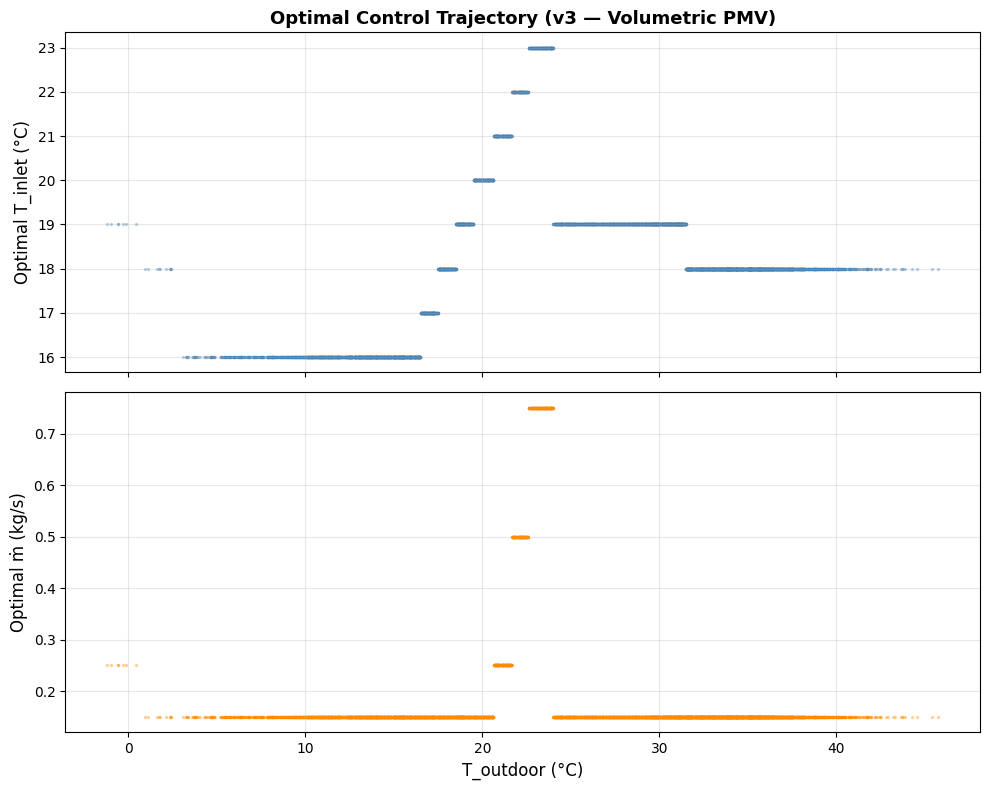

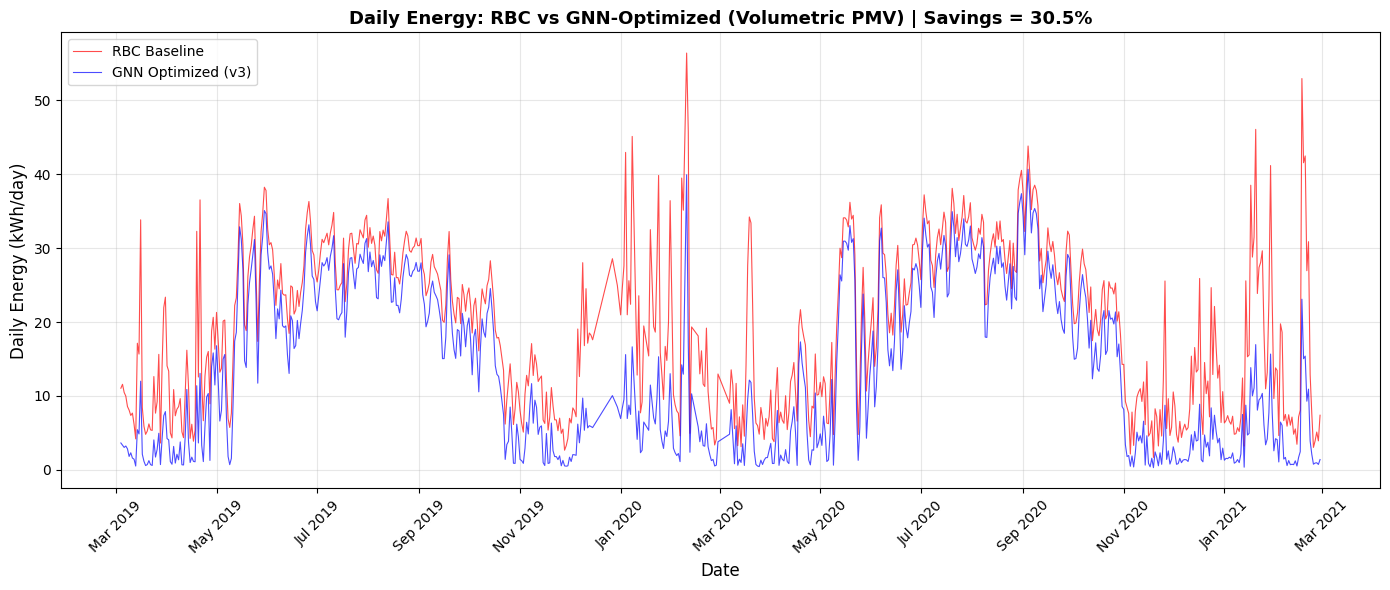


✅ Complete. Saved: optimized_hourly_v3.csv, optimal_trajectory_v3.png, Q_rbc_vs_optimized_v3.png


In [29]:
# ============================================================
# STEP 3: HOURLY OPTIMIZATION (v3 — volumetric PMV)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ─── Load lookup table ────────────────────────────────────────
lut = np.load("gnn_lookup_table_v3.npz")
T_out_grid   = lut["T_out_grid"]
T_in_grid    = lut["T_in_grid"]
mdot_grid    = lut["mdot_grid"]
vol_mean_PMV = lut["vol_mean_PMV"]
dT_vert      = lut["dT_vert"]
vol_pct_comf = lut["vol_pct_comf"]

CP = 1006.43

# Feasibility: |vol_mean_PMV| ≤ 0.5 AND |T_head - T_ankle| < 3°C
feasible = (np.abs(vol_mean_PMV) <= 0.5) & (dT_vert < 3.0)

# ─── Load hourly weather ──────────────────────────────────────
rbc = pd.read_csv("rbc_baseline_hourly.csv")
rbc['datetime'] = pd.to_datetime(rbc['datetime'])
print(f"Hours to optimize: {len(rbc)}")

# ─── Optimize each hour ──────────────────────────────────────
opt_tin = []
opt_mdot = []
opt_Q = []
opt_vol_pmv = []
opt_vol_pct = []
opt_dT = []
opt_feasible = []

for idx, row in rbc.iterrows():
    t_out = row['T_outdoor_C']
    
    # Find nearest T_outdoor bin
    i = np.argmin(np.abs(T_out_grid - t_out))
    
    # Get feasible points
    fj, fk = np.where(feasible[i])
    
    if len(fj) == 0:
        opt_tin.append(np.nan)
        opt_mdot.append(np.nan)
        opt_Q.append(np.nan)
        opt_vol_pmv.append(np.nan)
        opt_vol_pct.append(np.nan)
        opt_dT.append(np.nan)
        opt_feasible.append(False)
        continue
    
    # Compute Q for each feasible point using actual T_outdoor
    Q_feas = np.array([
        mdot_grid[fk[n]] * CP * abs(T_in_grid[fj[n]] - t_out) / 1000
        for n in range(len(fj))
    ])
    
    best = np.argmin(Q_feas)
    
    opt_tin.append(float(T_in_grid[fj[best]]))
    opt_mdot.append(float(mdot_grid[fk[best]]))
    opt_Q.append(Q_feas[best])
    opt_vol_pmv.append(float(vol_mean_PMV[i, fj[best], fk[best]]))
    opt_vol_pct.append(float(vol_pct_comf[i, fj[best], fk[best]]))
    opt_dT.append(float(dT_vert[i, fj[best], fk[best]]))
    opt_feasible.append(True)

# Add to dataframe
rbc['opt_T_inlet'] = opt_tin
rbc['opt_mdot'] = opt_mdot
rbc['opt_Q_kW'] = opt_Q
rbc['opt_vol_PMV'] = opt_vol_pmv
rbc['opt_vol_pct_comf'] = opt_vol_pct
rbc['opt_dT_vert'] = opt_dT
rbc['opt_feasible'] = opt_feasible

n_feasible = sum(opt_feasible)
print(f"Feasible: {n_feasible} / {len(rbc)} ({100*n_feasible/len(rbc):.1f}%)")

# ─── Save ─────────────────────────────────────────────────────
rbc.to_csv("optimized_hourly_v3.csv", index=False)
print(f"Saved: optimized_hourly_v3.csv")

# ─── Stats ────────────────────────────────────────────────────
feas = rbc[rbc['opt_feasible']]

print(f"\n{'='*60}")
print("OPTIMIZATION RESULTS (v3 — volumetric PMV)")
print(f"{'='*60}")
print(f"  Optimal T_inlet range: {feas['opt_T_inlet'].min():.0f} – {feas['opt_T_inlet'].max():.0f} °C")
print(f"  Optimal ṁ range:       {feas['opt_mdot'].min():.2f} – {feas['opt_mdot'].max():.2f} kg/s")
print(f"  Optimal Q range:       {feas['opt_Q_kW'].min():.2f} – {feas['opt_Q_kW'].max():.2f} kW")
print(f"  Mean optimal Q:        {feas['opt_Q_kW'].mean():.2f} kW")
print(f"  Total optimal energy:  {feas['opt_Q_kW'].sum():.1f} kWh")
print(f"  Total RBC energy:      {rbc['Q_kWh'].sum():.1f} kWh")
savings = (1 - feas['opt_Q_kW'].sum() / rbc['Q_kWh'].sum()) * 100
print(f"  Energy savings:        {savings:.1f}%")

print(f"\n  Volumetric comfort:")
print(f"  Mean vol_PMV:          {feas['opt_vol_PMV'].mean():.3f}")
print(f"  Mean vol_pct_comf:     {feas['opt_vol_pct_comf'].mean():.1f}%")

# ─── ṁ distribution ──────────────────────────────────────────
print(f"\n  ṁ selection distribution:")
mdot_counts = feas['opt_mdot'].apply(lambda x: round(x, 2)).value_counts().sort_index()
for mdot_val, count in mdot_counts.items():
    print(f"    ṁ = {mdot_val:.2f}: {count} hours ({100*count/n_feasible:.1f}%)")

# ─── ṁ breakdown by T_outdoor ────────────────────────────────
print(f"\n  ṁ by T_outdoor range:")
for mdot_val in sorted(feas['opt_mdot'].apply(lambda x: round(x, 2)).unique()):
    subset = feas[np.isclose(feas['opt_mdot'], mdot_val, atol=0.01)]
    if len(subset) > 0:
        print(f"    ṁ ≈ {mdot_val:.2f} ({len(subset)} hrs): T_out = {subset['T_outdoor_C'].min():.1f}–{subset['T_outdoor_C'].max():.1f}°C, "
              f"T_in = {subset['opt_T_inlet'].min():.0f}–{subset['opt_T_inlet'].max():.0f}°C")

# ─── Plot 1: Optimal trajectory ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1 = axes[0]
ax1.scatter(feas['T_outdoor_C'], feas['opt_T_inlet'], s=2, alpha=0.3, c='steelblue')
ax1.set_ylabel('Optimal T_inlet (°C)', fontsize=12)
ax1.set_title('Optimal Control Trajectory (v3 — Volumetric PMV)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(feas['T_outdoor_C'], feas['opt_mdot'], s=2, alpha=0.3, c='darkorange')
ax2.set_xlabel('T_outdoor (°C)', fontsize=12)
ax2.set_ylabel('Optimal ṁ (kg/s)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("optimal_trajectory_v3.png", dpi=200, bbox_inches='tight')
plt.show()

# ─── Plot 2: Q over time — RBC vs Optimized ──────────────────
rbc['date'] = rbc['datetime'].dt.date
daily_rbc = rbc.groupby('date')['Q_kWh'].sum().reset_index()
daily_rbc['date'] = pd.to_datetime(daily_rbc['date'])

daily_opt = feas.groupby(feas['datetime'].dt.date)['opt_Q_kW'].sum().reset_index()
daily_opt.columns = ['date', 'Q_opt_kWh']
daily_opt['date'] = pd.to_datetime(daily_opt['date'])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_rbc['date'], daily_rbc['Q_kWh'], linewidth=0.8, color='red', alpha=0.7, label='RBC Baseline')
ax.plot(daily_opt['date'], daily_opt['Q_opt_kWh'], linewidth=0.8, color='blue', alpha=0.7, label='GNN Optimized (v3)')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Energy (kWh/day)', fontsize=12)
ax.set_title(f'Daily Energy: RBC vs GNN-Optimized (Volumetric PMV) | Savings = {savings:.1f}%',
            fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Q_rbc_vs_optimized_v3.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✅ Complete. Saved: optimized_hourly_v3.csv, optimal_trajectory_v3.png, Q_rbc_vs_optimized_v3.png")